In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name='tenx_5K_pbmc_rnaseq',
    as_zarr=True,
    save_path='scarf_datasets'
)

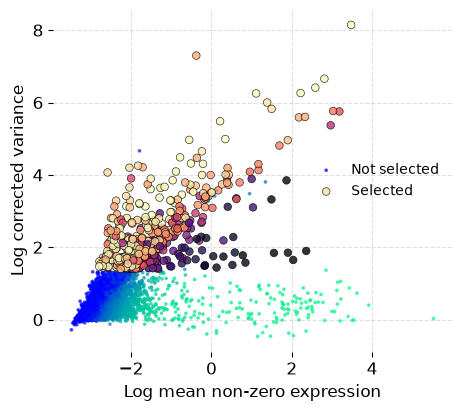

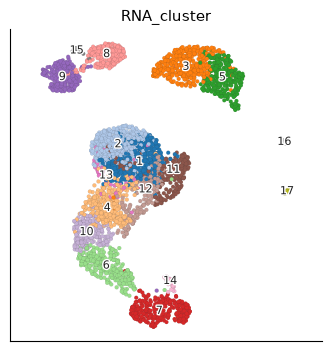

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [3]:
ds = scarf.DataStore('scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr')

ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key='hvgs', k=11, dims=15)
ds.run_clustering(n_clusters=15)
ds.run_umap(n_epochs=250, parallel=True)

splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='RNA_cluster',
)

In [4]:
ds.run_topacedo_sampler(
    cluster_key='RNA_cluster',
    max_sampling_rate=0.1
)

Constructing graph from dendrogram:   0%|          | 0/3939 [00:00<?, ?it/s]

Constructing graph from dendrogram: 100%|██████████| 3939/3939 [00:00<00:00, 193744.44it/s]

INFO: 392 cells (9.95%) sub-sampled. Subsample to Seed (166 cells) ratio: 2.361


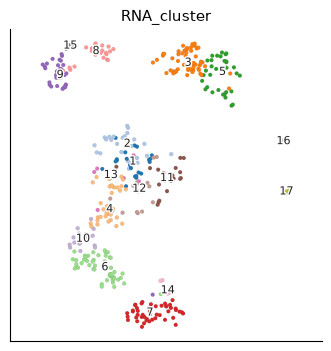

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [5]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='RNA_cluster',
    subset_by='RNA_sketched',
)

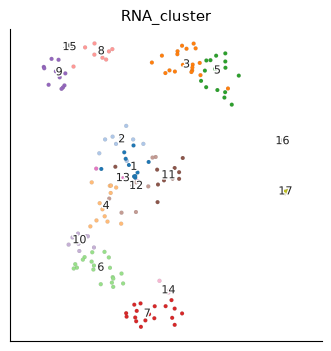

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [6]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='RNA_cluster',
    subset_by='RNA_sketch_seeds',
)

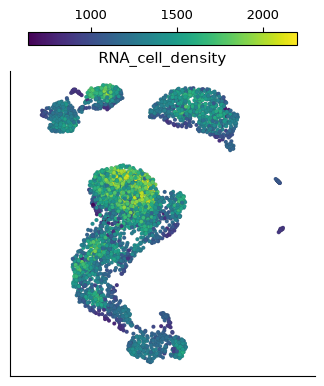

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [7]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='RNA_cell_density',
)

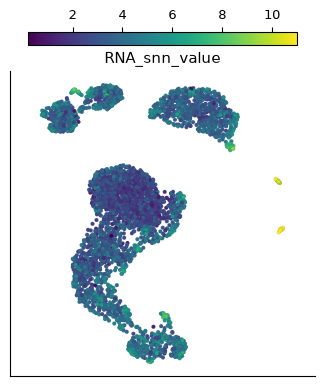

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [8]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='RNA_snn_value',
)

In [9]:
writer = scarf.SubsetZarr(
    zarr_loc='scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr',
    assays=[ds.RNA],
    cell_key='RNA_sketched',
    reset_cell_filter=False
)
writer.dump()

In [10]:
ds2 = scarf.DataStore('scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr')

In [11]:
ds2

DataStore has 392 (392) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_tSNE2', 
            'RNA_cell_density', 'RNA_snn_value', 'RNA_tSNE1', 'RNA_sketch_seeds', 'RNA_percentRibo', 
            'RNA_nFeatures', 'RNA_nCounts', 'RNA_cluster', 'RNA_UMAP2', 'RNA_leiden_cluster', 
            'RNA_sketched', 'RNA_UMAP1'
   RNA assay has 8869 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

In [12]:
adata = ds2.to_anndata()

In [13]:
adata

AnnData object with n_obs × n_vars = 392 × 33538
    obs: 'I', 'names', 'RNA_percentMito', 'RNA_tSNE2', 'RNA_cell_density', 'RNA_snn_value', 'RNA_tSNE1', 'RNA_sketch_seeds', 'RNA_percentRibo', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_leiden_cluster', 'RNA_cluster', 'RNA_sketched', 'RNA_UMAP2', 'RNA_UMAP1'
    var: 'I', 'names', 'nCells', 'dropOuts'